# 16 - Decision Tree Classification

> 📘 **Instructor Curriculum**

### The story

You run a small coaching centre. Ten students sat the exam. Five passed, five failed.

You tracked only two things about each of them:

- did the student watch the video lessons? (`5me`, renamed to `yt` below)
- did the student have a guide, a mentor? (`guide`)

A new batch joins tomorrow. You want to tell them one honest sentence: **"do this, and you will pass."**

So which of the two actually decides the result - the videos, or the guide?

### Why this needs a decision tree

As a Java developer you would write this by hand:

```java
if (watchedVideos) {
    if (hasGuide) return PASS;
    ...
}
```

You choose the conditions, and you choose which one to check first, from your own experience.

A decision tree writes those `if` conditions **from the data itself** - including the order to check them in. That is the only difference, and it is the whole idea.

### Where this is used in real life

Same shape, different business:

| The question | The columns |
| --- | --- |
| Approve this loan? | salary, credit history, existing EMIs |
| Is this chest pain urgent? | age, blood pressure, ECG |
| Will this customer leave us? | plan, complaints, last login |
| Send this order to fraud review? | amount, country, age of card |

Banks and hospitals like trees for one reason: **a tree can explain its answer**. You can print the rules and show them to an auditor. Most other models cannot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/Users/kaliprasad/Documents/MACHINE_LEARNING/AI_ML_Series/02_data_toolkit_apps/02_pandas/DataSet/exam.csv')

In [3]:
data

,5me,guide,result
0,0,0,fail
1,1,1,pass
2,1,0,pass
3,0,0,fail
4,0,0,fail
5,1,1,pass
6,0,1,fail
7,1,1,pass
8,1,0,fail
9,1,1,pass


## Step 1 - The problem: you are confused

`data.result.value_counts()` counts each value in a column.

Here is the whole class on one screen. **P = passed, F = failed.** Every diagram below moves these same ten letters around, so you can always check the answer by counting.

```
  row     0   1   2   3   4   5   6   7   8   9
  ─────────────────────────────────────────────
  videos  0   1   1   0   0   1   0   1   1   1
  guide   0   1   0   0   0   1   1   1   0   1
  result  F   P   P   F   F   P   F   P   F   P
                          │
                          ▼
        one pile:   F P P F F P F P F P
                    5 pass  /  5 fail
```

If a student walked in right now, your best answer would be a coin flip. **That confusion is the thing we are trying to remove.**

To remove it you ask a question and split the pile. But you have two possible questions and can only ask one first. So before anything else, you need a number for confusion.

In [4]:
data.result.value_counts()

result
fail    5
pass    5
Name: count, dtype: int64

## Step 2 - Entropy: putting a number on confusion

Entropy is the doubt in a pile, as a number between 0 and 1.

```
   pile                E        how sure are you?
   ──────────────────────────────────────────────────────────
   P P P P P P P P    0.00     ████████████  certain
   P P P P P P P F    0.54     ███████░░░░░  nearly certain
   P P P P P P F F    0.81     ████░░░░░░░░  leaning
   P P P P P F F F    0.95     ██░░░░░░░░░░  barely leaning
   P P P P F F F F    1.00     ░░░░░░░░░░░░  coin flip
```

- **0** = pure. Every row has the same answer.
- **1** = fully mixed. 50/50. You know nothing.

```
E = -P(pass) * log2(P(pass))  -  P(fail) * log2(P(fail))
```

`np.log2(x)` is log to base 2. Base 2 is chosen so a 50/50 pile lands on exactly 1.

Our pile is 5 pass / 5 fail, so **E = 1.0** - the worst score there is. Everything below is an attempt to bring this number down.

In [5]:
entropy_results = -(5/10)*np.log2(5/10) -(5/10)*np.log2(5/10)
entropy_results

np.float64(1.0)

## Step 3 - Ask the first question: "did you watch the videos?"

Send the class into two rooms. Video watchers in one, the rest in the other. Then look at how messy each room is.

Two bits of syntax for that:

- `data.rename(columns={'5me':'yt'}, inplace=True)` renames a column. `inplace=True` edits `data` itself instead of handing back a copy.
- `data[data.yt == 1]` is a **boolean mask**. `data.yt == 1` builds a True/False column, and `data[...]` keeps only the True rows. This is the "send them into a room" step.

In [6]:
data.rename(columns = {'5me':'yt'}, inplace = True)

In [7]:
data

,yt,guide,result
0,0,0,fail
1,1,1,pass
2,1,0,pass
3,0,0,fail
4,0,0,fail
5,1,1,pass
6,0,1,fail
7,1,1,pass
8,1,0,fail
9,1,1,pass


In [8]:
data[data.yt == 1]

,yt,guide,result
1,1,1,pass
2,1,0,pass
5,1,1,pass
7,1,1,pass
8,1,0,fail
9,1,1,pass


In [9]:
entropy_results_yt_yes = -(5/6)*np.log2(5/6) -(1/6)*np.log2(1/6)
entropy_results_yt_yes

np.float64(0.6500224216483541)

In [10]:
data[data.yt == 0]

,yt,guide,result
0,0,0,fail
3,0,0,fail
4,0,0,fail
6,0,1,fail


In [11]:
data

,yt,guide,result
0,0,0,fail
1,1,1,pass
2,1,0,pass
3,0,0,fail
4,0,0,fail
5,1,1,pass
6,0,1,fail
7,1,1,pass
8,1,0,fail
9,1,1,pass


This is where the ten students actually go:

```
                        ALL 10 STUDENTS
                       F P P F F P F P F P
                       5 pass / 5 fail        E = 1.00
                                │
              ┌───── did you watch the videos? ─────┐
           NO │                                     │ YES
              ▼                                     ▼
      rows 0, 3, 4, 6                    rows 1, 2, 5, 7, 8, 9
         F  F  F  F                         P  P  P  P  F  P
      0 pass / 4 fail                      5 pass / 1 fail
         E = 0.00                             E = 0.65
   ✔ clean room, question over         one student out of place
```

The left room is **pure** - not one video-skipper passed. Its entropy is 0, which is why the next cell writes `(4/10) * 0` instead of a formula.

## Step 4 - One number for both rooms

The rooms are different sizes, so a plain average would lie. Weight each room by how many students are in it:

```
    room          size      E        share × E
    ──────────────────────────────────────────
    NO videos     4/10     0.00        0.000
    YES videos    6/10     0.65        0.390
    ──────────────────────────────────────────
                        E(after) =     0.39
```

Same idea as averaging response time across two servers - the one taking more traffic counts more.

In [12]:
yt_entropy = (6/10) * entropy_results_yt_yes +  (4/10) * 0
yt_entropy

np.float64(0.39001345298901247)

## Step 5 - Information gain: was the question worth asking?

```
   before  ██████████████████████████████  1.00
   after   ███████████░░░░░░░░░░░░░░░░░░░  0.39
           └──────────┘
            removed 0.61   ← the information gain
```

```
Information Gain = confusion before - confusion after = 1.00 - 0.39 = 0.61
```

This is the **score of the question**. Like interviewing: the question worth asking first is the one that tells you the most about the candidate.

In [13]:
info_yt = entropy_results - (6/10) * entropy_results_yt_yes -  (4/10) * 0
info_yt

np.float64(0.6099865470109875)

## Step 6 - Give the other question a fair chance

Forget that split. Put all ten back in one pile and split on the guide instead.

```
                        ALL 10 STUDENTS
                       F P P F F P F P F P
                       5 pass / 5 fail        E = 1.00
                                │
              ┌────── did you have a guide? ───────┐
           NO │                                    │ YES
              ▼                                    ▼
      rows 0, 2, 3, 4, 8                   rows 1, 5, 6, 7, 9
         F  P  F  F  F                        P  P  F  P  P
      1 pass / 4 fail                       4 pass / 1 fail
         E = 0.72                              E = 0.72
   ✘ still messy                        ✘ still messy
```

Neither room came out clean. Each one still hides a surprise student.

In [14]:
data[data.guide == 1]

,yt,guide,result
1,1,1,pass
5,1,1,pass
6,0,1,fail
7,1,1,pass
9,1,1,pass


In [15]:
entropy_results_guide_yes = -(4/5)*np.log2(4/5) -(1/5)*np.log2(1/5)
entropy_results_guide_yes

np.float64(0.7219280948873623)

In [16]:
data[data.guide == 0]

,yt,guide,result
0,0,0,fail
2,1,0,pass
3,0,0,fail
4,0,0,fail
8,1,0,fail


In [17]:
entropy_results_guide_no = -(1/5)*np.log2(1/5) -(4/5)*np.log2(4/5)
entropy_results_guide_no

np.float64(0.7219280948873623)

In [18]:
guide_entropy = (5/10) * entropy_results_guide_yes +  (5/10) * entropy_results_guide_no
guide_entropy

np.float64(0.7219280948873623)

In [19]:
info_guide = entropy_results - guide_entropy
info_guide

np.float64(0.2780719051126377)

## Step 7 - Pick the winner

Put the two splits side by side and you can see it without any maths:

```
      SPLIT ON VIDEOS                       SPLIT ON GUIDE
   ─────────────────────────            ─────────────────────────
    F F F F  │  P P P P F P              F P F F F  │  P P F P P
    E = 0.00 │  E = 0.65                 E = 0.72   │  E = 0.72
        ▲                                     ▲          ▲
   one room is perfectly clean          both rooms still mixed

    left over  0.39                      left over  0.72
    removed    0.61   ★ WINNER           removed    0.28
```

| Question | Confusion left | Information gain |
| --- | --- | --- |
| watched the videos | 0.39 | **0.61** |
| had a guide | 0.72 | 0.28 |

So **"did you watch the videos?" becomes the first question the tree asks.**

### Round 2 - repeat inside the messy room

The clean room is finished. Only the six video-watchers are still mixed, so run the same contest again on them - with `guide`, the column that is left:

```
        rows 1, 2, 5, 7, 8, 9
           P P P P F P            E = 0.65
                  │
        ┌──── did you have a guide? ────┐
     NO │                               │ YES
        ▼                               ▼
     rows 2, 8                    rows 1, 5, 7, 9
       P  F                         P  P  P  P
     E = 1.00                       E = 0.00
   ✘ stuck, cannot split further   ✔ clean, done
```

Nothing is left to ask, so the tree stops. **That is the finished model** - and it is the same tree scikit-learn builds below.

Your honest sentence for the new batch: *"watch the videos."*

In [20]:
print(info_yt)

0.6099865470109875


In [21]:
print(info_guide)

0.2780719051126377


## Step 8 - Hand it over to scikit-learn

You just did this by hand for 2 columns and 10 rows. Real data has 30 columns and a lakh rows. Nobody does that by hand - that is what the library is for. Everything below is the same maths, running faster.

`LabelEncoder` turns text labels into numbers, because the model can compare numbers, not the words "pass" and "fail".
`fit_transform` = `fit` (learn the labels, sorted alphabetically) + `transform` (replace them).

So **fail → 0, pass → 1**. Hold on to that order - it decides how you read every result below.

In [22]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()          # create the encoder that will learn the text-to-number mapping
df = data                    # NOT a copy - df and data point to the same table in memory
df.result = le.fit_transform(df.result)   # fit: sort unique labels (fail, pass) -> 0, 1; transform: replace each value
df


,yt,guide,result
0,0,0,0
1,1,1,1
2,1,0,1
3,0,0,0
4,0,0,0
5,1,1,1
6,0,1,0
7,1,1,1
8,1,0,0
9,1,1,1


## Step 9 - Separate the questions from the answer

```
        x  (what you know)          y  (what happened)
       ┌──────┬────────┐              ┌────────┐
       │  yt  │ guide  │              │ result │
       ├──────┼────────┤              ├────────┤
       │  0   │   0    │              │   0    │
       │  1   │   1    │              │   1    │
       │ ...  │  ...   │              │  ...   │
       └──────┴────────┘              └────────┘
        a table (DataFrame)            one column (Series)
        df[['yt','guide']]             df['result']
        TWO brackets                   ONE bracket
```

Features always go in as a table, the answer as a single column.

In [24]:
x = df[['yt','guide']]
y = df['result']

## Step 10 - Train

`criterion='entropy'` tells sklearn to use the same formula you used by hand. The default is `'gini'`, a different mess-meter that nearly always builds the same tree. We pick entropy so the numbers match ours.

`dt.fit(x, y)` runs Steps 1 to 7 by itself, over and over, until it runs out of useful questions.

**What `fit` leaves behind:** the question at each node, and the fail/pass counts in each box. That is the whole model - a rulebook, nothing more. This is exactly why you can print a tree and defend it in a meeting.

In [25]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [26]:
dt = DecisionTreeClassifier(criterion='entropy')

In [27]:
dt.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

## Step 11 - Read the rulebook it wrote

`export_graphviz(dt, 'dt.tree', feature_names=['yt','guide'])` writes the tree out to a text file in DOT format. The next cell draws the same tree as a picture, right here in the notebook.

Here is that tree with your ten students still visible inside it:

```
                       yt <= 0.5 ?          ← "did you watch the videos?"
                       E = 1.00   n = 10
                       [5 fail, 5 pass]
                              │
           TRUE ┌─────────────┴─────────────┐ FALSE
      (yt = 0)  │                           │  (yt = 1)
                ▼                           ▼
        rows 0, 3, 4, 6              guide <= 0.5 ?
           F F F F                   E = 0.65   n = 6
        E = 0.00  n = 4              [1 fail, 5 pass]
        [4 fail, 0 pass]                    │
             → FAIL          TRUE ┌─────────┴─────────┐ FALSE
                                  ▼                   ▼
                            rows 2, 8           rows 1, 5, 7, 9
                              P  F                 P P P P
                            E = 1.00  n = 2      E = 0.00  n = 4
                            [1 fail, 1 pass]     [0 fail, 4 pass]
                              → tie                  → PASS
```

**Compare it with your Round 2 drawing in Step 7 - it is the same tree, student for student.** The library found the same first question, the same second question, and the same numbers: 1.00 → 0.65 → 0.00.

Two reading notes: `value = [5, 5]` means `[fail count, pass count]` (the LabelEncoder order), and `yt <= 0.5` is only sklearn's way of writing `yt == 0` - it always splits numbers with `<=`.

In [28]:
export_graphviz(dt,'dt.tree',feature_names=['yt','guide'])

Same tree, drawn by sklearn itself.

- **orange** = this box leans fail, **blue** = it leans pass, and the stronger the colour the purer the box.
- the **white** box is the 50/50 one - rows 2 and 8, the two students no question can separate.
- `class = fail` on the white box is sklearn breaking the tie by picking the lower class. That single choice is what costs you the 0.1 in Step 13.

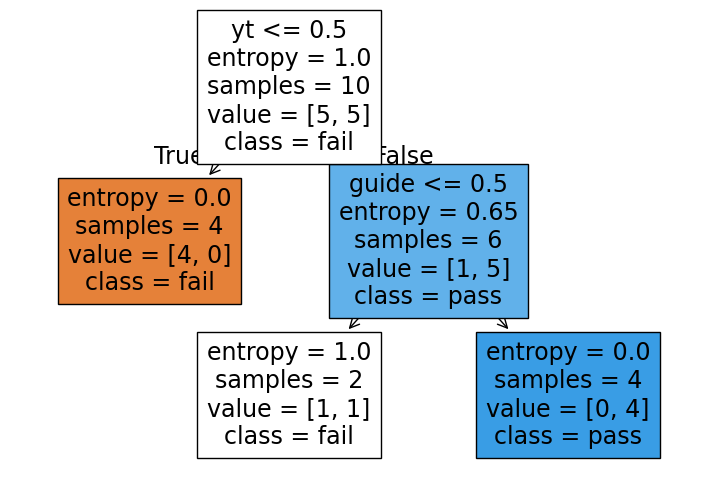

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(9, 6))
plot_tree(dt, feature_names=['yt', 'guide'], class_names=['fail', 'pass'], filled=True)
plt.show()

## Step 12 - A new student walks in

`dt.predict([[1, 1]])` - a student who watched the videos and had a guide.
Double brackets, because predict always expects a *table of rows*, even for one student.

Walk him down yourself:

```
   new student: videos = 1, guide = 1
            │
            ▼
   yt <= 0.5 ?  →  NO   ──────────────→ go right
            │
            ▼
   guide <= 0.5 ?  →  NO ──────────────→ go right
            │
            ▼
   box [0 fail, 4 pass]  →  answer: 1 = PASS
```

That short walk is all that happens in production. Training is the slow part; answering is two `if` checks. This is why trees are used where the answer has to come back in milliseconds.

The warning only means the model was trained with column names but asked with a bare list. Harmless. Silence it with `pd.DataFrame([[1,1]], columns=['yt','guide'])`.

In [30]:
dt.predict([[1,1]])

/Users/kaliprasad/Documents/MACHINE_LEARNING/pizza_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

## Step 13 - How good is it, honestly?

`dt.score(x, y)` = accuracy = the share of rows it gets right. It says **0.9**, not 1.0.

Drop all ten students into the three final boxes and mark each one:

```
  ┌─ no videos ────────┐ ┌─ videos, no guide ─┐ ┌─ videos + guide ───┐
  │ rows 0, 3, 4, 6    │ │ rows 2, 8          │ │ rows 1, 5, 7, 9    │
  │ truth:   F F F F   │ │ truth:   P    F    │ │ truth:   P P P P   │
  │ tree says: FAIL    │ │ tree says: FAIL    │ │ tree says: PASS    │
  │          ✓ ✓ ✓ ✓   │ │          ✗    ✓    │ │          ✓ ✓ ✓ ✓   │
  └────────────────────┘ └────────────────────┘ └────────────────────┘

                 9 ticks, 1 cross  →  9 / 10  =  0.9
```

That one cross is not a bug:

| row | watched videos | had guide | result |
| --- | --- | --- | --- |
| 2 | yes | no | **pass** |
| 8 | yes | no | **fail** |

Same answer to every question, opposite outcome. The tree cannot separate them - and neither could you. Real data is full of this: two customers with identical profiles, one leaves and one stays. The box must pick a side, it picks fail, so row 2 is marked wrong.

Two honest warnings before you trust that number:

- We scored on the same 10 rows we trained on. That is a memory test, not an ability test. Real evaluation needs [01_train_test_split_data.ipynb](01_train_test_split_data.ipynb).
- Let a tree grow deep enough and it invents a rule for every single student. Perfect on this data, useless on the next batch. The usual fix is to grow many small trees and let them vote - Random Forest, the next topic in your notes.

**If you remember only one thing:** a decision tree keeps asking *"which question removes the most confusion?"* Entropy measures the confusion. Information gain is the drop.

In [31]:
dt.score(x,y)

0.9